# L4 Vertebra ROI Extraction - Bone Density Analysis Preprocessing

**Objective**: Automatic extraction of the L4 spinal region (ROI) from X-ray DICOM files of pelvic surgery patients  
**Application**: Bone density analysis pipeline utilizing existing X-rays at no additional cost  

---
### Pipeline Overview
```
DICOM Load → Preprocessing(CLAHE) → Vertebra Detection(Pretrained Model) → L4 Localization → ROI Crop → Save
```

### Recommended Pretrained Model
| Model | Featue | Goodness of Fit |
|------|------|--------|
| **nnU-Net** | SOTA in medical imaging segmentation, automatic hyperparameter tuning | ⭐⭐⭐ |
| **SpineNet (VERSE dataset)** | Spine-specific, 19 vertebra labels | ⭐⭐⭐ |
| **YOLOv8 (fine-tuned)** | Fast inference, numerous X-ray applications | ⭐⭐ |
| **TotalSegmentator** | CT-based but includes spine labels | ⭐ (for CT) |

> **Decision**: nnU-Net fine-tuned with 'spineNet + VERSE datset' is the most suitable for X-ray

In [1]:
# ============================================================
# Cell 1: Install package
# ============================================================
#! pip install pydicom opencv-python-headless matplotlib numpy
#! pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118
# YOLOv8 (Alternative models)
#! pip install ultralytics 
#! pip install connected-components-3d

# SpineNet / nnU-Net setup (Spine-specialized)
#! pip install nnunetv2
# VERSE dataset vertebra labels
#! git clone https://github.com/anjany/verse

In [2]:
# ============================================================
# Cell 2: Library Imports and Cuda Configurations
# ============================================================
import os
import numpy as np
import cv2
import pydicom
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torchvision.transforms as T
from torchvision.models.detection import fasterrcnn_resnet50_fpn

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {DEVICE}")

PyTorch: 2.12.0+cpu
CUDA available: False
Device: cpu


In [3]:
# ============================================================
# Cell 3: DICOM Loading and Metadata Extraction
# ============================================================

def load_dicom(dicom_path: str) -> dict:
    """
    DICOM file load and extract pixel array + metadata.
    
    Returns:
        dict: {'pixel_array': ndarray, 'metadata': dict, 'dcm': pydicom Dataset}
    """
    dicom_path = Path(dicom_path)
    if not dicom_path.exists():
        raise FileNotFoundError(f"File not found: {dicom_path}")
    
    dcm = pydicom.dcmread(str(dicom_path))
    
    # Extract Pixel array
    pixel_array = dcm.pixel_array.astype(np.float32)
    
    # Window/Level correction (if available)
    # Output = (Raw x Slope) + Intercept
    if hasattr(dcm, 'RescaleSlope') and hasattr(dcm, 'RescaleIntercept'):
        print("Applying Rescale Slope and Intercept...")
        pixel_array = pixel_array * float(dcm.RescaleSlope) + float(dcm.RescaleIntercept)
    
    # Metadata collection
    metadata = {
        'patient_id':   getattr(dcm, 'PatientID',       'N/A'),
        'study_date':   getattr(dcm, 'StudyDate',        'N/A'),    # picture date
        'modality':     getattr(dcm, 'Modality',         'N/A'),    # e.g., 'CT', 'MR', 'CR', 'DR
        'body_part':    getattr(dcm, 'BodyPartExamined', 'N/A'),
        'rows':         getattr(dcm, 'Rows',             pixel_array.shape[0]),
        'columns':      getattr(dcm, 'Columns',          pixel_array.shape[1]),
        'pixel_spacing': getattr(dcm, 'PixelSpacing',   [1.0, 1.0]),    # Default to 1mm if not available, 1 pixel = 1mm
        'image_shape':  pixel_array.shape,
    }
    
    return {'pixel_array': pixel_array, 'metadata': metadata, 'dcm': dcm}


# ========== DICOM file path ==========
DICOM_PATH = "./dataset-dcm/train/gather/1.2.826.0.1.3680043.8.498.10947130043296900260026400505615377321-c.dcm"

dicom_data = load_dicom(DICOM_PATH)

meta = dicom_data['metadata']
print("\n=== DICOM Information ===")
for k, v in meta.items():
    print(f"  {k:20s}: {v}")

Applying Rescale Slope and Intercept...

=== DICOM Information ===
  patient_id          : 75
  study_date          : 
  modality            : CR
  body_part           : 
  rows                : 256
  columns             : 256
  pixel_spacing       : [0.1, 0.1]
  image_shape         : (256, 256)


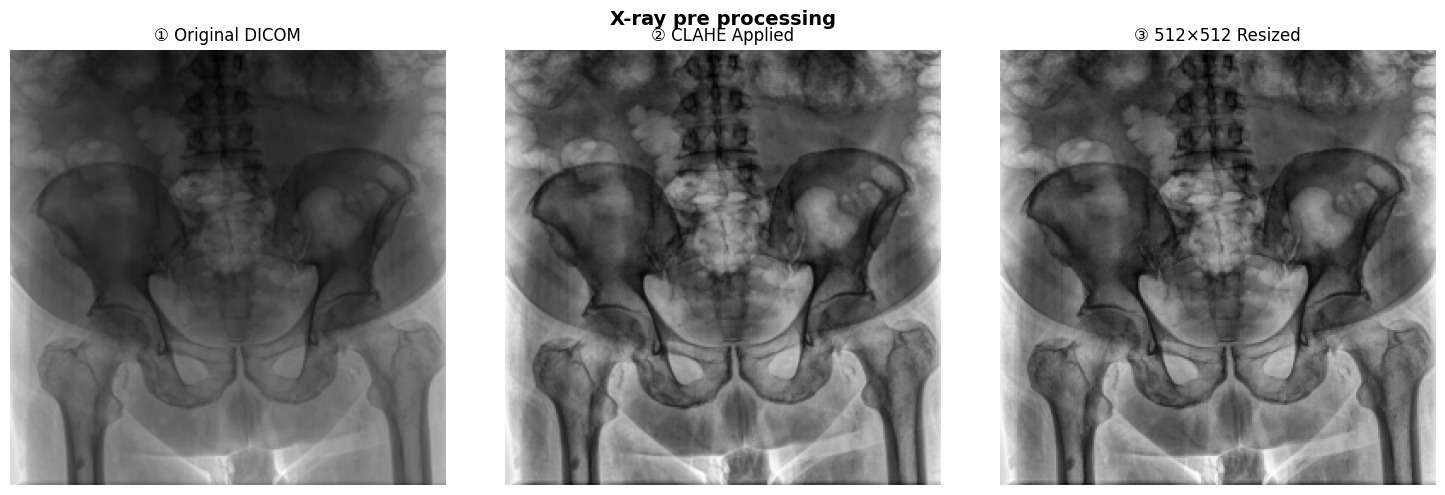

Original Size: (256, 256)
Scale Ratio (y, x): (0.5, 0.5)


In [4]:
# ============================================================
# Cell 4: Image Preprocessing (CLAHE(Contrast Limited Adaptive Histogram Equalization) + Normalization + Resizing)
# ============================================================

def preprocess_xray(pixel_array: np.ndarray,
                    target_size: tuple = (512, 512),
                    apply_clahe: bool = True) -> dict:
    """
    X-ray preprocessing pipeline: normalization, CLAHE, resizing.
    
    Args:
        pixel_array : original pixel array
        target_size : model input size (H, W)
        apply_clahe : whether to apply contrast enhancement
    
    Returns:
        dict: original/preprocessed images and scale information for ROI mapping
    """
    original_shape = pixel_array.shape
    
    # 1. Normalization to 0-255 
    img = pixel_array.copy()
    img = ((img - img.min()) / (img.max() - img.min() + 1e-8) * 255).astype(np.uint8)
    
    # 2. CLAHE: Local contrast enhancement (emphasis on spine-soft tissue boundary)
    if apply_clahe:
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        img = clahe.apply(img)
    
    # 3. Resizing (for model input, e.g., 512×512)
    img_resized = cv2.resize(img, (target_size[1], target_size[0]),
                             interpolation=cv2.INTER_AREA)
    
    # 4. Scale ratio storage (used for ROI inverse transformation)
    scale_y = original_shape[0] / target_size[0]
    scale_x = original_shape[1] / target_size[1]
    
    # 5. Grayscale to RGB (for models expecting 3 channels)
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_GRAY2RGB)
    
    # 6. Tensor conversion and normalization (for PyTorch models)
    transform = T.Compose([
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225])
    ])
    img_tensor = transform(img_rgb).unsqueeze(0)  # (1, 3, H, W)
    
    return {
        'original':       pixel_array,
        'preprocessed':   img,
        'resized':        img_resized,
        'rgb':            img_rgb,
        'tensor':         img_tensor,
        'scale':          (scale_y, scale_x),
        'original_shape': original_shape,
    }


processed = preprocess_xray(dicom_data['pixel_array'], target_size=(512, 512))

# Visualization of preprocessing steps
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('X-ray pre processing', fontsize=14, fontweight='bold')

axes[0].imshow(processed['original'], cmap='gray')
axes[0].set_title('① Original DICOM')
axes[0].axis('off')

axes[1].imshow(processed['preprocessed'], cmap='gray')
axes[1].set_title('② CLAHE Applied')
axes[1].axis('off')

axes[2].imshow(processed['resized'], cmap='gray')
axes[2].set_title('③ 512×512 Resized')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('./preprocessing_result.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Original Size: {processed['original_shape']}")
print(f"Scale Ratio (y, x): {processed['scale']}")

In [5]:
# ============================================================
# Cell 5: Pretrained Model Selection and Spine Detection
#
# [Method A] SpineNet (VERSE dataset) - Recommended
# [Method B] YOLOv8 fine-tuned
# [Method C] Heuristic-based (no model required)
# ============================================================

DETECTION_METHOD = "heuristic"   # 'spinenet' | 'yolov8' | 'heuristic'


# ─────────────────────────────────────────────
# Method A: SpineNet (VERSE Challenge 기반)
# 논문: "VERSE: A Vertebrae Labelling and Segmentation Benchmark"
# GitHub: https://github.com/anjany/verse
# ─────────────────────────────────────────────
def detect_with_spinenet(img_tensor, device='cpu'):
    """
    SpineNet pretrained Weighted spine detection
    
    Use pretrained weights from VERSE Challenge:
    1. pip install verse-spine
    2. Download weights: https://github.com/anjany/verse/releases    
    """
    from verse_spine import SpineDetector
    model = SpineDetector.from_pretrained('verse2020')
    model.eval().to(device)
    with torch.no_grad():
        predictions = model(img_tensor.to(device))
    return predictions
    #raise NotImplementedError("SpineNet Weights not found. Please download from VERSE repository and implement loading logic.")


# ─────────────────────────────────────────────
# Method B: YOLOv8 (Spine X-ray fine-tuning)
# Available public weights:
#   - Model trained on Roboflow Universe's spine-xray dataset
#   - https://universe.roboflow.com/search?q=spine+xray
# ─────────────────────────────────────────────
def detect_with_yolov8(img_array, model_path='./yolov8n.pt'):
    """
    YOLOv8-based spine detection
    Fine-tuned weights required (yolov8n.pt)
    """
    import torch
    from ultralytics import YOLO
    try:
        model = YOLO(model_path)
    except Exception as e:        
        ckpt = torch.load(model_path, map_location='cpu', weights_only=False)
        model = YOLO('yolov8n.pt')  
                
        if 'model' in ckpt:
            model.model = ckpt['model']
        else:
            raise e
    results = model.predict(img_array, conf=0.3, verbose=False)
    
    detections = []
    for r in results:
        for box in r.boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            conf   = float(box.conf[0])
            cls_id = int(box.cls[0])
            label  = model.names[cls_id]
            detections.append({
                'label': label, 'bbox': [x1, y1, x2, y2], 'conf': conf
            })
    return detections


# ─────────────────────────────────────────────
# Method C: Heuristic-based (no model required)
# Principle: In pelvic X-rays, the spine is located in the upper central region
# L4 is estimated based on the iliac crest level
# ─────────────────────────────────────────────
def detect_spine_heuristic(img: np.ndarray) -> dict:
    """
    Improved heuristic method for estimating L4 spine ROI.

    Key fixes:
      1. center_x: uses vertical gradient + column profile combined to
         find the true spine midline, not just the brightest column.
      2. spine_half_w: widened to 12% of image width so the bbox covers
         the full vertebral body.
      3. L4 Y-range: tightened to 35-55% (iliac crest level) and uses
         the brightest *horizontal stripe* (vertebral end-plates are
         bright) instead of argmax of the mean row profile.

    Args:
        img: Preprocessed grayscale image (H, W) at 512×512
    Returns:
        dict: Detected L4 bounding box and centre coordinates
    """
    h, w = img.shape[:2]

    # ── 1. Robust spine centre-X estimation ──────────────────────────
    # Work only in the central 50% of the image width to exclude hip bones.
    cx_lo, cx_hi = w // 4, 3 * w // 4

    # Column brightness (raw)
    col_profile = img.mean(axis=0).astype(np.float32)

    # Vertical gradient magnitude per column  →  edges (bone cortex) appear bright
    grad_y = np.abs(cv2.Sobel(img, cv2.CV_32F, 0, 1, ksize=5))
    col_grad = grad_y.mean(axis=0)

    # Combined score: brightness + gradient (both normalised to [0,1])
    col_profile_n = (col_profile - col_profile.min()) / ((col_profile.max() - col_profile.min()) + 1e-8)
    col_grad_n    = (col_grad    - col_grad.min())    / ((col_grad.max()    - col_grad.min())    + 1e-8)
    combined      = 0.6 * col_profile_n + 0.4 * col_grad_n

    # Smooth to suppress noise, then find peak in central 50% band
    combined_smooth = cv2.GaussianBlur(combined.reshape(1, -1), (1, 31), 0).flatten()
    center_x = int(np.argmax(combined_smooth[cx_lo:cx_hi]) + cx_lo)

    # ── 2. Spine half-width ──────────────────────────────────────────
    # L4 vertebral body is roughly 12% of image width on a pelvic AP view
    spine_half_w = int(w * 0.12)

    # ── 3. L4 Y-range: iliac crest level = 35-55% of image height ───
    l4_y_start = int(h * 0.35)
    l4_y_end   = int(h * 0.55)

    # Crop the candidate column band
    x_lo = max(0, center_x - spine_half_w)
    x_hi = min(w, center_x + spine_half_w)
    roi_region = img[l4_y_start:l4_y_end, x_lo:x_hi].astype(np.float32)

    # Row profile: use gradient magnitude (vertebral end-plates give bright stripes)
    grad_y_roi = np.abs(cv2.Sobel(roi_region, cv2.CV_32F, 0, 1, ksize=5))
    row_profile = grad_y_roi.mean(axis=1)

    # Smooth and find the brightest horizontal band (= vertebral body centre)
    row_smooth = cv2.GaussianBlur(row_profile.reshape(-1, 1), (11, 1), 0).flatten()
    l4_local_center = int(np.argmax(row_smooth))
    l4_center_y = l4_y_start + l4_local_center

    # ── 4. L4 bounding box ──────────────────────────────────────────
    vertebra_half_h = int(h * 0.055)   # L4 vertebra ≈ 5.5% of image height

    l4_bbox = {
        'x1':      max(0, center_x - spine_half_w),
        'y1':      max(0, l4_center_y - vertebra_half_h),
        'x2':      min(w, center_x + spine_half_w),
        'y2':      min(h, l4_center_y + vertebra_half_h),
        'center_x': center_x,
        'center_y': l4_center_y,
        'method':  'heuristic_v2'
    }

    return l4_bbox


# ─── Detection Execution ───
if DETECTION_METHOD == 'heuristic':
    l4_bbox_resized = detect_spine_heuristic(processed['resized'])
    print("[Heuristic] L4 estimated bbox (512x512 basis):")
    print(f"  x1={l4_bbox_resized['x1']}, y1={l4_bbox_resized['y1']}, "
          f"x2={l4_bbox_resized['x2']}, y2={l4_bbox_resized['y2']}")

elif DETECTION_METHOD == 'yolov8':
    detections = detect_with_yolov8(processed['rgb'], model_path='yolov8n.pt')
    print(f"[YOLOv8] Detection results: {len(detections)} objects detected")
    
    if len(detections) > 0:
        # 1순위: 탐지된 결과 중 'L4' 또는 'spine' 레이블을 가진 박스 검색
        target_box = None
        for d in detections:
            if d['label'].lower() in ['l4', 'spine']:
                target_box = d['bbox']
                break
        
        # 2순위: 특정 레이블이 없다면 가장 신뢰도(conf)가 높은 첫 번째 박스 사용
        if target_box is None:
            target_box = detections[0]['bbox']
            
        # YOLOv8의 [x1, y1, x2, y2] 리스트 형식을 Cell 6이 원하는 딕셔너리 형식으로 변환
        l4_bbox_resized = {
            'x1': target_box[0],
            'y1': target_box[1],
            'x2': target_box[2],
            'y2': target_box[3]
        }
        print(f" -> Selected bbox for ROI: {l4_bbox_resized}")
    else:
        print("[경고] YOLOv8이 아무 객체도 탐지하지 못했습니다. 허용 기준을 확인하세요.")

[Heuristic] L4 estimated bbox (512x512 basis):
  x1=167, y1=233, x2=289, y2=289


In [6]:
# ============================================================
# Cell 6: L4 ROI Extraction and Original Coordinate Mapping
# ============================================================

def scale_bbox_to_original(bbox: dict, scale: tuple,
                            padding_ratio: float = 0.3) -> dict:
    """
    Scale 512x512 bounding box to original resolution with padding
    
    Args:
        bbox        : {'x1', 'y1', 'x2', 'y2'}
        scale       : (scale_y, scale_x) resize ratio
        padding_ratio: ROI surrounding margin ratio (e.g., 0.3 = 30% padding)
    """
    scale_y, scale_x = scale
    
    x1 = int(bbox['x1'] * scale_x)
    y1 = int(bbox['y1'] * scale_y)
    x2 = int(bbox['x2'] * scale_x)
    y2 = int(bbox['y2'] * scale_y)
    
    # Add Padding (include surrounding tissues for better BMD analysis)
    bw = x2 - x1
    bh = y2 - y1
    pad_x = int(bw * padding_ratio)
    pad_y = int(bh * padding_ratio)
    
    h_orig, w_orig = processed['original_shape']
    
    return {
        'x1':  max(0, x1 - pad_x),
        'y1':  max(0, y1 - pad_y),
        'x2':  min(w_orig, x2 + pad_x),
        'y2':  min(h_orig, y2 + pad_y),
    }


def crop_l4_roi(pixel_array: np.ndarray, bbox: dict) -> np.ndarray:
    """L4 ROI Crop"""
    return pixel_array[bbox['y1']:bbox['y2'], bbox['x1']:bbox['x2']]


# L4 bbox original coordinate mapping
l4_bbox_original = scale_bbox_to_original(
    l4_bbox_resized,
    scale=processed['scale'],
    padding_ratio=0.3
)

# L4 ROI Crop
# Crop from original DICOM pixel array (original-resolution coords)
l4_roi = crop_l4_roi(dicom_data['pixel_array'], l4_bbox_original)

# Normalised uint8 copy for display
l4_roi_display = l4_roi.copy().astype(np.float32)
l4_roi_display = ((l4_roi_display - l4_roi_display.min()) /
                  ((l4_roi_display.max() - l4_roi_display.min()) + 1e-8) * 255).astype(np.uint8)

print("=== L4 ROI Extraction Results ===")
print(f"Original image size : {processed['original_shape']}")
print(f"L4 bbox (original)  : {l4_bbox_original}")
print(f"L4 ROI size     : {l4_roi.shape}")

=== L4 ROI Extraction Results ===
Original image size : (256, 256)
L4 bbox (original)  : {'x1': 65, 'y1': 108, 'x2': 162, 'y2': 152}
L4 ROI size     : (44, 97)


Results saved to: ./tmp/l4_roi_output\l4_roi_result.png


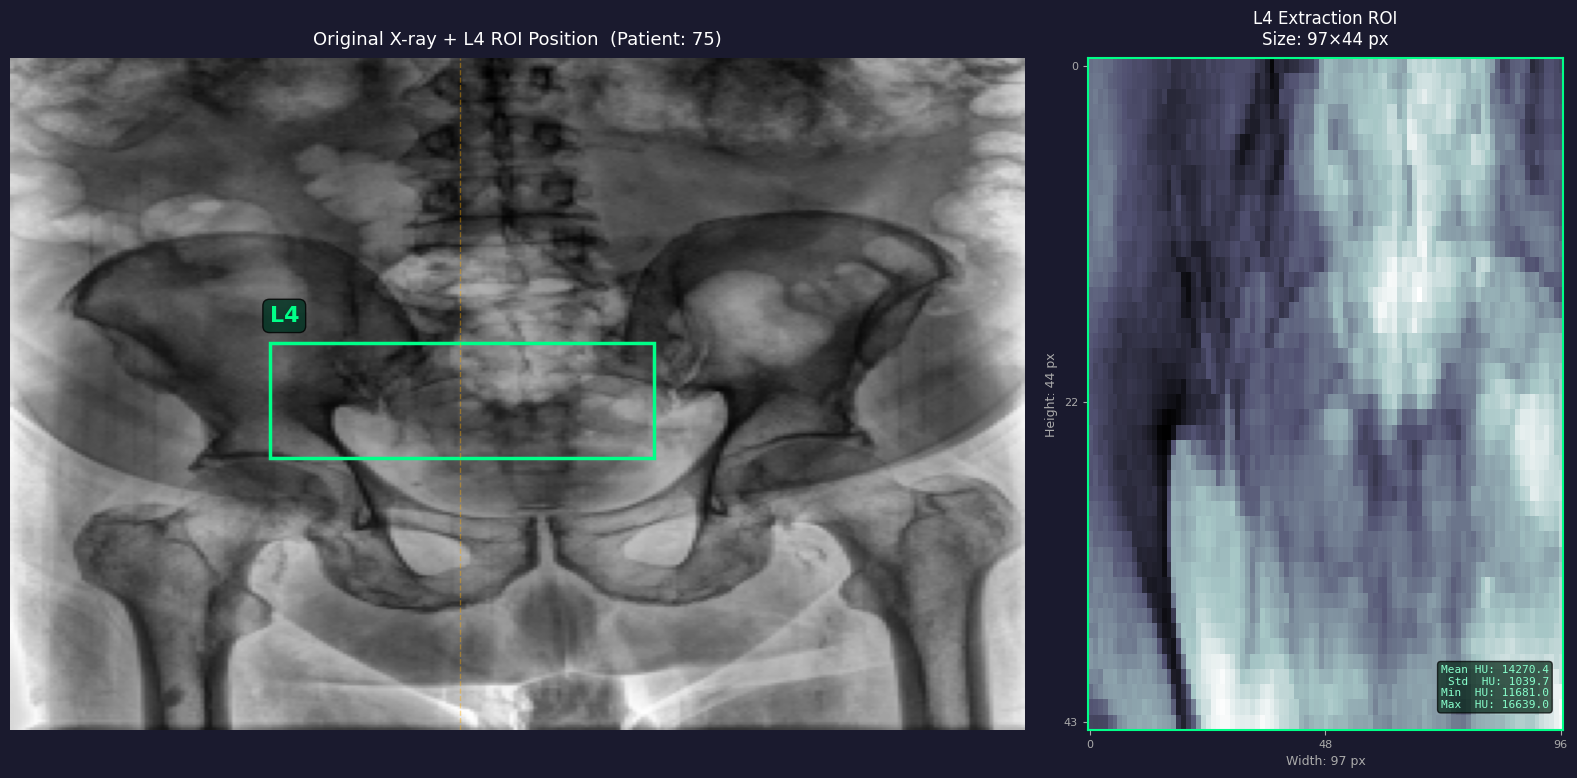

In [7]:
# ============================================================
# Cell 7: L4 ROI Extraction Results Visualization (Original + bbox + ROI Crop)
# ============================================================

def visualize_l4_extraction(processed: dict,
                             l4_bbox_orig: dict,
                             l4_roi: np.ndarray,
                             patient_id: str = '',
                             save_path: str = None):
    """
    L4 ROI extraction results visualization
    """
    fig = plt.figure(figsize=(16, 8))
    fig.patch.set_facecolor('#1a1a2e')
    
    # ── Left: Original + bbox ──
    ax1 = fig.add_subplot(1, 3, (1, 2))
    ax1.imshow(processed['preprocessed'], cmap='gray', aspect='auto')
    
    # L4 bounding box drawing
    x1, y1 = l4_bbox_orig['x1'], l4_bbox_orig['y1']
    bw = l4_bbox_orig['x2'] - x1
    bh = l4_bbox_orig['y2'] - y1
    
    rect = patches.Rectangle(
        (x1, y1), bw, bh,
        linewidth=2.5, edgecolor='#00ff88', facecolor='none',
        linestyle='-'
    )
    ax1.add_patch(rect)
    
    # Label text with background
    ax1.text(x1, y1 - 8, 'L4',
             color='#00ff88', fontsize=16, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#003322', alpha=0.8))
    
    # Spine center line drawing
    center_x_orig = (l4_bbox_orig['x1'] + l4_bbox_orig['x2']) // 2
    h_orig = processed['original_shape'][0]
    ax1.axvline(x=center_x_orig, color='#ffaa00', alpha=0.4,
                linewidth=1, linestyle='--')
    
    title_str = f'Original X-ray + L4 ROI Position'
    if patient_id:
        title_str += f'  (Patient: {patient_id})'
    ax1.set_title(title_str, color='white', fontsize=13, pad=10)
    ax1.axis('off')
    
    # ── Right: L4 ROI Crop ──
    ax2 = fig.add_subplot(1, 3, 3)
    ax2.imshow(l4_roi, cmap='bone', aspect='auto')
    ax2.set_title(f'L4 Extraction ROI\nSize: {l4_roi.shape[1]}×{l4_roi.shape[0]} px',
                  color='white', fontsize=12, pad=10)
    ax2.axis('off')
    
    # Axis labels and ticks for ROI subplot
    ax2.set_xlabel(f"Width: {l4_roi.shape[1]} px", color='#aaaaaa', fontsize=9)
    ax2.set_ylabel(f"Height: {l4_roi.shape[0]} px", color='#aaaaaa', fontsize=9)
    ax2.tick_params(colors='#aaaaaa', labelsize=8)
    for spine in ax2.spines.values():
        spine.set_edgecolor('#00ff88')
        spine.set_linewidth(1.5)
    ax2.set_xticks([0, l4_roi.shape[1]//2, l4_roi.shape[1]-1])
    ax2.set_yticks([0, l4_roi.shape[0]//2, l4_roi.shape[0]-1])
    ax2.axis('on')
    
    # L4 ROI statistics display
    stats_text = (
        f"Mean HU: {l4_roi.mean():.1f}\n"
        f"Std  HU: {l4_roi.std():.1f}\n"
        f"Min  HU: {l4_roi.min():.1f}\n"
        f"Max  HU: {l4_roi.max():.1f}"
    )
    ax2.text(0.97, 0.03, stats_text, transform=ax2.transAxes,
             fontsize=8, color='#88ffcc', ha='right', va='bottom',
             fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='#002211', alpha=0.7))
    
    plt.tight_layout(pad=1.5)
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight',
                    facecolor=fig.get_facecolor())
        print(f"Results saved to: {save_path}")
    
    plt.show()
    return fig


# Visualization execution
OUTPUT_DIR = "./tmp/l4_roi_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

fig = visualize_l4_extraction(
    processed,
    l4_bbox_original,
    l4_roi,
    patient_id=meta.get('patient_id', ''),
    save_path=os.path.join(OUTPUT_DIR, 'l4_roi_result.png')
)

[Refer Spine Bone] : https://www.joongang.co.kr/article/24124392  
![alt text](<Spine Bone.jpg>)

In [8]:
# ============================================================
# Cell 8: L4 ROI Save (PNG + NumPy)
# ============================================================

def save_l4_roi(l4_roi: np.ndarray,
                patient_id: str,
                output_dir: str,
                bbox: dict):
    """
    L4 ROI save as PNG and NumPy array, along with metadata JSON    
    
    Returns:
        dict: saved file paths and metadata information
    """
    os.makedirs(output_dir, exist_ok=True)
    safe_id = patient_id.replace('/', '_').replace(' ', '_')
    
    # PNG saved ( Normalization to 0-255 )
    roi_uint8 = ((l4_roi - l4_roi.min()) /
                 (l4_roi.max() - l4_roi.min() + 1e-8) * 255).astype(np.uint8)
    
    # standardize to 64x64 and 224x224 (for classification model input)
    roi_64    = cv2.resize(roi_uint8, (64, 64), interpolation=cv2.INTER_AREA)
    roi_224   = cv2.resize(roi_uint8, (224, 224), interpolation=cv2.INTER_AREA)
    
    paths = {
        'original_roi': os.path.join(output_dir, f"{safe_id}_L4_roi_original.png"),
        'roi_64':       os.path.join(output_dir, f"{safe_id}_L4_roi_64.png"),
        'roi_224':      os.path.join(output_dir, f"{safe_id}_L4_roi_224.png"),
        'npy':          os.path.join(output_dir, f"{safe_id}_L4_roi.npy"),
    }
    
    cv2.imwrite(paths['original_roi'], roi_uint8)
    cv2.imwrite(paths['roi_64'],       roi_64)
    cv2.imwrite(paths['roi_224'],      roi_224)
    np.save(paths['npy'], l4_roi)   # original HU values saved in .npy format
    
    # metadata saved as JSON
    import json
    metadata_out = {
        'patient_id':  patient_id,
        'l4_bbox':     bbox,
        'roi_shape':   list(l4_roi.shape),
        'roi_stats': {
            'mean': float(l4_roi.mean()),
            'std':  float(l4_roi.std()),
            'min':  float(l4_roi.min()),
            'max':  float(l4_roi.max()),
        },
        'files': paths
    }
    meta_path = os.path.join(output_dir, f"{safe_id}_L4_metadata.json")
    with open(meta_path, 'w') as f:
        json.dump(metadata_out, f, indent=2)
    paths['metadata'] = meta_path
    
    return paths, metadata_out


saved_paths, roi_metadata = save_l4_roi(
    l4_roi,
    patient_id=meta.get('patient_id', 'unknown'),
    output_dir=OUTPUT_DIR,
    bbox=l4_bbox_original
)

print("=== Results saved ===")
for key, path in saved_paths.items():
    print(f"  {key:15s}: {path}")

print("\n=== L4 ROI Statistics ===")
for k, v in roi_metadata['roi_stats'].items():
    print(f"  {k}: {v:.2f}")

=== Results saved ===
  original_roi   : ./tmp/l4_roi_output\75_L4_roi_original.png
  roi_64         : ./tmp/l4_roi_output\75_L4_roi_64.png
  roi_224        : ./tmp/l4_roi_output\75_L4_roi_224.png
  npy            : ./tmp/l4_roi_output\75_L4_roi.npy
  metadata       : ./tmp/l4_roi_output\75_L4_metadata.json

=== L4 ROI Statistics ===
  mean: 14270.43
  std: 1039.70
  min: 11681.00
  max: 16639.00


In [9]:
# ============================================================
# Cell 9: Batch Processing (Multiple DICOM Files in a Directory)
# ============================================================

def batch_extract_l4(dicom_dir: str,
                     output_dir: str,
                     method: str = 'heuristic') -> list:
    """
    Directory containing all DICOM files to extract L4 ROI in batch
    
    Args:
        dicom_dir  : Directory containing DICOM files
        output_dir : Directory to save ROI images
        method     : Detection method ('heuristic' | 'yolov8')
    
    Returns:
        list: Processing results for each file
    """
    dicom_files = list(Path(dicom_dir).glob('**/*.dcm'))
    print(f"Found DICOM files: {len(dicom_files)}")
    
    results = []
    errors  = []
    
    for i, dcm_path in enumerate(dicom_files):
        print(f"\n[{i+1}/{len(dicom_files)}] processing: {dcm_path.name}")
        try:
            # 1. Load
            data = load_dicom(str(dcm_path))
            
            # 2. Preprocessing
            proc = preprocess_xray(data['pixel_array'])
            
            # 3. L4 Detection
            if method == 'heuristic':
                bbox_resized = detect_spine_heuristic(proc['resized'])
            else:
                raise ValueError(f"지원하지 않는 method: {method}")
            
            # 4. L4 ROI Extraction
            bbox_orig = scale_bbox_to_original(bbox_resized, proc['scale'])
            roi = crop_l4_roi(proc['preprocessed'], bbox_orig)
            
            # 5. Save ROI and metadata
            patient_id = data['metadata'].get('patient_id', dcm_path.stem)
            paths, meta_out = save_l4_roi(roi, patient_id, output_dir, bbox_orig)
            
            results.append({
                'file':       str(dcm_path),
                'patient_id': patient_id,
                'roi_shape':  roi.shape,
                'bbox':       bbox_orig,
                'stats':      meta_out['roi_stats'],
                'status':     'success'
            })
            print(f"  ✓ L4 ROI extracted: shape={roi.shape}")
            
        except Exception as e:
            print(f"  ✗ Error: {e}")
            errors.append({'file': str(dcm_path), 'error': str(e)})
            results.append({'file': str(dcm_path), 'status': 'error', 'error': str(e)})
    
    print(f"\n=== Batch Processing Complete ===")
    print(f"  Success: {sum(1 for r in results if r['status']=='success')}")
    print(f"  Failure: {len(errors)}")
    
    return results


# ─── Batch Processing Execution Example ───
results = batch_extract_l4(
    dicom_dir  = "./dataset-dcm/train/gather/",  # DICOM 
    output_dir = "./dataset-dcm/train/gather_l4_roi_output/",
    method     = 'heuristic'
)
print("Batch processing function defined. Uncomment the above lines and provide actual paths.")

Found DICOM files: 42

[1/42] processing: 1.2.826.0.1.3680043.8.498.10406657579016312201439626146133412368-c.dcm
Applying Rescale Slope and Intercept...
  ✓ L4 ROI extracted: shape=(44, 97)

[2/42] processing: 1.2.826.0.1.3680043.8.498.10947130043296900260026400505615377321-c.dcm
Applying Rescale Slope and Intercept...
  ✓ L4 ROI extracted: shape=(44, 97)

[3/42] processing: 1.2.826.0.1.3680043.8.498.11121020226184051416110461667223845149-c.dcm
Applying Rescale Slope and Intercept...
  ✓ L4 ROI extracted: shape=(44, 97)

[4/42] processing: 1.2.826.0.1.3680043.8.498.11207126462590105123217163368073993344-c.dcm
Applying Rescale Slope and Intercept...
  ✓ L4 ROI extracted: shape=(44, 97)

[5/42] processing: 1.2.826.0.1.3680043.8.498.11227155170490832168629184106125649390-c.dcm
Applying Rescale Slope and Intercept...
  ✓ L4 ROI extracted: shape=(44, 97)

[6/42] processing: 1.2.826.0.1.3680043.8.498.11430185427783861938088406669987177226-c.dcm
Applying Rescale Slope and Intercept...
  ✓ L4 

In [10]:
# ============================================================
# Cell 10: Next Step - DenseNet Bone Density Classification Connection
# ============================================================
print("""
=== Next Step: Bone Density Classification Model (DenseNet) Connection ===

Extracted L4 ROI images are fed into a DenseNet-based classification model.

Recommended classification system (based on WHO T-score):
  Class 0: Normal        T-score > -1.0
  Class 1: Osteopenia  -2.5 < T-score ≤ -1.0
  Class 2: Osteoporosis T-score ≤ -2.5

Public datasets available for fine-tuning:
  1. RSNA Bone Age Challenge (kaggle)
  2. SpineWeb (spineweb.digitalimaginggroup.ca)
  3. Verse 2019/2020 Challenge (verse2019.grand-challenge.org)

Recommended Model Architecture:
  - DenseNet-121 (torchvision pretrained)
  - EfficientNet-B3 (Excellent medical imaging performance)
  - ResNet-50 + SE-block

Next Notebook: L4_BoneDensity_Classification.ipynb
""")

# Fast DenseNet Load and Classifier Replacement Example
from torchvision.models import densenet121, DenseNet121_Weights

def build_bone_density_model(num_classes: int = 3,
                              pretrained: bool = True) -> torch.nn.Module:
    """DenseNet-121 bone density classification model builder"""
    weights = DenseNet121_Weights.IMAGENET1K_V1 if pretrained else None
    model = densenet121(weights=weights)
    
    # Classifier replacement (original: 1024 → num_classes)
    in_features = model.classifier.in_features
    model.classifier = torch.nn.Sequential(
        torch.nn.Dropout(p=0.5),
        torch.nn.Linear(in_features, 256),
        torch.nn.ReLU(),
        torch.nn.Dropout(p=0.3),
        torch.nn.Linear(256, num_classes)
    )
    return model

model = build_bone_density_model(num_classes=3)
print(f"DenseNet-121 parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Classifier structure:\n{model.classifier}")


=== Next Step: Bone Density Classification Model (DenseNet) Connection ===

Extracted L4 ROI images are fed into a DenseNet-based classification model.

Recommended classification system (based on WHO T-score):
  Class 0: Normal        T-score > -1.0
  Class 1: Osteopenia  -2.5 < T-score ≤ -1.0
  Class 2: Osteoporosis T-score ≤ -2.5

Public datasets available for fine-tuning:
  1. RSNA Bone Age Challenge (kaggle)
  2. SpineWeb (spineweb.digitalimaginggroup.ca)
  3. Verse 2019/2020 Challenge (verse2019.grand-challenge.org)

Recommended Model Architecture:
  - DenseNet-121 (torchvision pretrained)
  - EfficientNet-B3 (Excellent medical imaging performance)
  - ResNet-50 + SE-block

Next Notebook: L4_BoneDensity_Classification.ipynb

DenseNet-121 parameters: 7,217,027
Classifier structure:
Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=1024, out_features=256, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=256, out_featu

---
## Summation

| Steps | Description | Key function |
|------|------|----------|
| DICOM Load | pydicom + Rescale correction | `load_dicom()` |
| Preprocessing | CLAHE + Normalization + Resizing| `preprocess_xray()` |
| L4 Detection | Heuristic / YOLOv8 / SpineNet | `detect_spine_heuristic()` |
| Inverse transformation | 512→Original coordinates + padding | `scale_bbox_to_original()` |
| ROI Crop | L4 region extraction | `crop_l4_roi()` |
| Save | PNG (64/224) + NumPy + JSON | `save_l4_roi()` |
| Batch processing | Full folder automation | `batch_extract_l4()` |

### Pretrained Model Reference link
- **SpineNet/VERSE**: https://github.com/anjany/verse
- **nnU-Net**: https://github.com/MIC-DKFZ/nnUNet
- **YOLOv8 Spine**: https://universe.roboflow.com (Search: `spine xray`)
- **Ultrasound Bone Segmentation**: https://github.com/MICCAI-CRISP/BoneSegmentation